# Generative Models

Generative models are a type of artificial intelligence (AI) that **learn the underlying structure of data** and use it to create **new, realistic samples**. 

These models can generate:
- **Text** (e.g., GPT, ChatGPT, Bard)
- **Images** (e.g., Stable Diffusion, Midjourney, DALL·E)
- **Music & Audio** (e.g., Jukebox, AudioLM)
- **Video & 3D Models** (e.g., RunwayML, NVIDIA StyleGAN)

Unlike **discriminative models**, which classify data (e.g., "Is this a cat or a dog?"), **generative models** create entirely new samples based on patterns they have learned.


### Classifying vs. Generating: A "Cats vs. Dogs" Example

Imagine we train an AI model to recognize images of **cats** and **dogs**.

1. **Discriminative Model (Classification)**
    - The AI looks at an image and predicts **"cat" or "dog"**.
    - It does this by learning patterns in pixel values and deciding which category is more likely.


2. **Generative Model**
   - Instead of just recognizing cats and dogs, a **generative model** learns the full probability distribution of what cat and dog images look like.
   - It then **generates entirely new images** that resemble real cats and dogs, even if they have never been seen before.

#### From Classification to Generation
- **Discriminative models** focus on **decision boundaries** (e.g., "This image is more likely a cat than a dog").
- **Generative models** learn how the entire dataset is structured and can **create new examples** that fit the learned patterns.

This ability to use **model distributions** is what allows generative AI to create **new text, images, and music** that seem real.

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2021/06/how-to-do-Cat-and-Dog-Classification-using-CNN_-How-to-do-Cat-and-Dog-Classification-using-CNN_-01-scaled.jpg)

## Types of Generative Models

| Model Type | How It Works | Pros | Cons | Example Applications |
|------------|-------------|------|------|----------------------|
| **VAEs** | Encode data into a latent space and decode it | Simple, interpretable | Lower-quality outputs | Handwritten digit generation |
| **GANs** | Competing networks generate and evaluate data | High-quality images | Unstable training | Deepfake images, AI art |
| **Normalizing Flows** | Transform distributions via invertible functions | Exact likelihood computation | Less scalable | Density estimation |
| **Diffusion Models** | Learn to reverse a noise-adding process | Excellent sample quality | Slow generation speed | Stable Diffusion, DALL·E 2 |
| **Transformers** | Generate sequences with attention mechanisms | Best for text generation | Computationally expensive | ChatGPT, DALL·E |

#### Variational Autoencoders (VAEs)
- VAEs learn to **compress** data into a low-dimensional space (called a **latent space**) and then **reconstruct it** back to the original form.
- They add a **random noise component** to ensure the model learns a flexible and smooth latent space.

#### Generative Adversarial Networks (GANs)
- GANs use two networks:
  - A **Generator** that creates fake images.
  - A **Discriminator** that tries to distinguish real images from fake ones.
- The **Generator** improves by continuously trying to "fool" the Discriminator.

#### Normalizing Flows
- These models transform **simple distributions (like Gaussian noise)** into **complex distributions** using a series of **invertible** transformations.
- The key idea is that every transformation keeps track of how probabilities change, so **exact likelihoods** can be computed.

#### Diffusion Models
- Inspired by **thermodynamic diffusion**, these models add noise to data step by step until it becomes **pure noise**.
- The model **learns to reverse this process**, gradually refining noisy data into realistic images.

#### Transformers (Large-Scale Generative Models)
- Transformers, such as **GPT-4, ChatGPT, and BERT**, use **self-attention** mechanisms to **generate coherent text**.
- When used for images, transformers generate **pixels or patches sequentially**, leading to models like **DALL·E and Imagen**.

---

# Normalizing Flows

## The Big Idea

Imagine you have a jar full of perfectly round marbles (simple, predictable data — like points drawn from a bell curve). Now imagine you could slowly reshape each marble, step by step, into a tiny, detailed sculpture — a cat, a face, a handwritten digit. And crucially, you could also reverse the process: take any sculpture and trace it back to the original marble it came from.

That is essentially what a **Normalizing Flow** does. It learns a chain of reversible transformations that warp a simple distribution (like Gaussian noise) into a complex one (like real-world images), and vice versa. Because every step is reversible, the model can:

- **Generate new data** by starting from random noise and "sculpting" it forward.
- **Evaluate exact probabilities** by mapping real data backward to the simple distribution and computing how likely the original noise point was.

This second property — exact likelihood computation — is what sets Normalizing Flows apart from other generative models. GANs cannot compute the probability of a given sample at all. VAEs can only approximate it. Normalizing Flows give you the **exact answer**.

## A More Formal View

Mathematically, we start with a latent variable drawn from a simple base distribution:

$$
z_0 \sim \mathcal{N}(0, I)
$$

We then apply a sequence of **invertible, differentiable** functions (called "flow steps"):

$$
z_k = f_k \circ f_{k-1} \circ \dots \circ f_1 (z_0)
$$

The result $z_k$ lives in the same space as our data but now follows a much more complex distribution. Because every $f_i$ is invertible, we can always go backward from $z_k$ to $z_0$, and we can compute the exact probability of $z_k$ using the **change of variables formula** (covered in detail below).

### Why "Normalizing" and Why "Flow"?

- **"Normalizing"** refers to the fact that the change of variables formula normalizes (adjusts) the probability density at each step so it always integrates to 1.
- **"Flow"** refers to the data "flowing" through a chain of transformations, like water through a series of pipes that reshape its path.

## Why Are Normalizing Flows Important?

| Advantage | Explanation |
|-----------|-------------|
| **Exact likelihood** | You can compute $p(x)$ precisely — useful for training, model comparison, and anomaly detection. |
| **Efficient sampling** | Generating new data is a single forward pass through the chain of transformations. |
| **Flexible modeling** | Stacking more flow steps lets you approximate arbitrarily complex distributions. |
| **Bidirectional** | The same model supports both generation (noise → data) and inference (data → noise). |

## Where Are Normalizing Flows Used?

- **Image generation** — Models like Glow generate photorealistic face images.
- **Density estimation** — Estimating the probability distribution of scientific data (e.g., particle physics, molecular conformations).
- **Variational inference** — Improving the flexibility of approximate posteriors in VAEs (covered later in this notebook).
- **Audio synthesis** — WaveGlow uses normalizing flows for real-time speech synthesis.

![](https://tikz.net/janosh/normalizing-flow.png)

## Element-Wise Operations and Shuffle Layers 

Normalizing Flows need to balance two competing goals:

1. **Stay invertible** — every transformation must be reversible so we can compute exact probabilities.
2. **Be expressive** — the model must capture complicated patterns in real data.

Think of it like building with LEGO: each individual brick (element-wise operation) is simple, but by rearranging how bricks connect (shuffle layers), you can build arbitrarily complex structures.

### Element-Wise Operation Layers

These layers apply **invertible functions independently to each dimension** of the input. Because each dimension is handled separately, the math stays simple — specifically, the Jacobian matrix (which tracks how probabilities change) is diagonal, making its determinant trivial to compute.

#### Affine Coupling Layers (used in RealNVP and Glow)

This is the most widely used building block in modern normalizing flows. The idea is clever:

1. **Split** the input into two halves: $x_A$ and $x_B$.
2. **Keep** $x_B$ unchanged.
3. **Transform** $x_A$ using scaling and translation values that are computed from $x_B$:

$$
x_A' = x_A \odot \exp(s(x_B)) + t(x_B)
$$

where $s$ and $t$ are neural networks that output the scale and translation parameters.

**Why is this invertible?** Because $x_B$ is unchanged, we always know $s(x_B)$ and $t(x_B)$, so we can easily reverse the transformation:

$$
x_A = (x_A' - t(x_B)) \odot \exp(-s(x_B))
$$

**Analogy:** Imagine encoding a message by shifting each letter by an amount determined by the previous word. Anyone who knows the previous word can decode it. The "previous word" here is $x_B$ — it stays the same, so decoding (inverting) is straightforward.

#### Planar and Radial Flows

These are simpler, older flow steps often used inside VAEs:

$$
z' = z + u \;\tanh\!\bigl(w^\top z + b\bigr)
$$

- $u$, $w$, $b$ are small sets of learnable parameters.
- The transformation is invertible under mild conditions on $u$ and $w$.
- The Jacobian determinant has a closed-form expression, so likelihood computation is fast.

These are less powerful than affine coupling layers but useful when you only need a few flow steps to enrich a simple posterior.

### Shuffle Layers

Here is the problem with element-wise operations: if $x_A$ is always dimensions 1–5 and $x_B$ is always dimensions 6–10, then dimensions 1–5 never directly interact with each other through the coupling layer — they only get transformed *based on* dimensions 6–10. The flow would have blind spots.

**Shuffle layers solve this** by rearranging which dimensions end up in $x_A$ vs. $x_B$ before each coupling layer. After shuffling, the next coupling layer operates on a different split, so over several layers every dimension gets to influence every other dimension.

#### Common Shuffling Strategies

| Approach | How It Works | Trade-off |
|----------|--------------|-----------|
| **Fixed permutation** | Randomly reorder dimensions once per layer. | Free (no parameters), but the ordering is not learned. |
| **Invertible 1×1 convolution** (Glow) | Multiply by a learned invertible matrix $W$: $x' = Wx$. | Learnable and more expressive, but slightly more expensive. |
| **Checkerboard / channel splits** (RealNVP) | For images, alternate between pixel positions or color channels. | Exploits spatial structure of images naturally. |

**Analogy:** Think of a deck of cards. Element-wise operations are like modifying individual cards (changing their color, adding a number). Shuffle layers are like riffle-shuffling the deck so that the next round of modifications hits a completely different arrangement of cards. After enough rounds, every card has been influenced by every other card.

## Invertibility and Bijectivity in Normalizing Flows

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQjQmSDyCnxhL8DLy0EcoXqaWX_Mpvqa32LFQ&s)

Everything in normalizing flows depends on the transformations being **invertible**. This section explains what that means and why it matters, building from basic math concepts.

### What Does Invertible Mean?

A function $f$ is **invertible** if there exists another function $f^{-1}$ that perfectly undoes it:

$$
f^{-1}(f(x)) = x \quad \text{for all } x
$$

**Everyday example:** Converting Celsius to Fahrenheit is invertible — given a Fahrenheit temperature, you can always recover the exact Celsius value. Squaring a number is *not* invertible in general, because both $3$ and $-3$ give $9$, so you cannot tell which one you started with.

In normalizing flows, invertibility means we can move freely in both directions:
- **Forward (generation):** noise $z_0$ → data $x$
- **Backward (inference):** data $x$ → noise $z_0$

If the function were not invertible, we would lose information when going forward, making it impossible to trace back and compute probabilities.

### What Does Bijective Mean?

A function $f: \mathbb{R}^n \to \mathbb{R}^n$ is **bijective** if it satisfies two properties:

**1. Injective (one-to-one):** Different inputs always produce different outputs.

$$
f(x_1) = f(x_2) \implies x_1 = x_2
$$

- $f(x) = 2x + 3$ is injective — every input maps to a unique output.
- $f(x) = x^2$ is **not** injective — both $2$ and $-2$ map to $4$.

**2. Surjective (onto):** Every possible output is reachable from some input.

- $f(x) = x^3$ is surjective over the reals — every real number has a cube root.
- $f(x) = e^x$ is **not** surjective over the reals — you can never get a negative output.

A function that is both injective and surjective is **bijective**, and every bijective function is automatically invertible.

### Why Must Normalizing Flows Be Bijective?

The change of variables formula — the equation that lets us compute exact probabilities — **only works when the transformation is bijective**. Here is the intuition:

- **Injectivity** ensures that each data point maps to exactly one latent point. Without this, multiple data points could "collapse" onto the same latent point, and we would not be able to assign them distinct probabilities.
- **Surjectivity** ensures that the model can reach any point in the output space. Without this, some valid data points would have zero probability under the model, regardless of training.

Together, bijectivity guarantees a clean, one-to-one correspondence between the simple distribution and the complex one, which is exactly what we need to compute likelihoods.

### Key Takeaways

| Property | What It Guarantees | What Breaks Without It |
|----------|--------------------|----------------------|
| Invertible | Can map forward and backward between distributions | Cannot compute likelihoods or do inference |
| Injective | Each output came from exactly one input | Probability mass "piles up" — likelihoods become undefined |
| Surjective | Every possible output is reachable | Model cannot represent parts of the data distribution |
| Bijective | All of the above | The entire framework falls apart |

This is why normalizing flow architectures (RealNVP, Glow, Invertible ResNets) are carefully designed so that every layer is bijective by construction.

## The Math Behind Normalizing Flows

To formalize Normalizing Flows, we rely on the **change of variables theorem** for probability distributions.

### Change of Variables Formula
If $z_0$ follows a known probability density function $p(z_0)$ and we apply an invertible transformation $f$, the new density function $p(z_k)$ is given by:

$$
p(z_k) = p(z_0) \left| \det \frac{d f^{-1}}{d z_k} \right|
$$

Taking the logarithm, we get:

$$
\log p(z_k) = \log p(z_0) - \sum_{i=1}^{k} \log \left| \det \frac{d f_i}{d z_{i-1}} \right|
$$

where the term:

$$
\det \frac{d f_i}{d z_{i-1}}
$$

represents the **Jacobian determinant** of the transformation $f_i$. This term is crucial because it accounts for how volume elements change under the transformation.

### Stacking Multiple Transformations
In a normalizing flow, we apply a sequence of transformations:

$$
z_k = f_k \circ f_{k-1} \circ \dots \circ f_1 (z_0)
$$

Each transformation modifies the density function in a controlled manner, making the final density estimation tractable.

## Normalizing Flows in Neural Networks

Normalizing Flows are often used in deep learning for generative modeling, variational inference, and Bayesian deep learning.

### Flow-Based Generative Models

Generative models aim to learn a mapping from a latent space (e.g., Gaussian noise) to a complex data distribution. In normalizing flows, this is achieved by applying a sequence of invertible transformations.

#### Example: RealNVP (Real-Valued Non-Volume Preserving)

RealNVP is a popular normalizing flow model that uses **affine coupling layers** to transform a simple distribution into a complex one.

- The transformation follows:

  $$
  x_B = x_B
  $$

  $$
  x_A = x_A \odot \exp(s(x_B)) + t(x_B)
  $$

  where:
  - $x_A, x_B$ are partitions of the input.
  - $s(x_B)$ and $t(x_B)$ are scaling and translation functions.
  - The transformation is **invertible**, allowing for efficient sampling and likelihood computation.

- **Why is this useful?**
  - It enables density estimation with **tractable log-likelihood computation**.
  - It allows training via **maximum likelihood estimation (MLE)**.


### Variational Autoencoders with Normalizing Flows

In Variational Autoencoders (VAEs), we approximate the true posterior $ p(z|x) $ with a simple distribution $ q(z|x) $, usually a Gaussian. However, this simplification can limit expressiveness.

By incorporating **normalizing flows**, we can transform the latent distribution into a more complex one:

$$
q(z) = q(z_0) \prod_{i=1}^{k} \left| \det \frac{d f_i}{d z_{i-1}} \right|
$$

where the sequence of transformations enhances the flexibility of the learned latent space.

#### Example: Planar Flows

A simple normalizing flow used in VAEs is the **planar flow**, which applies a transformation:

$$
z' = z + u \tanh(w^T z + b)
$$

where $ u, w, b $ are learnable parameters.

- The Jacobian determinant is:

  $$
  \left| 1 + u^T \tanh'(w^T z + b) w \right|
  $$

- This transformation allows the posterior distribution to model complex dependencies.


### Bayesian Deep Learning with Normalizing Flows

In Bayesian deep learning, we aim to estimate **posterior distributions** over neural network weights. Normalizing Flows help approximate these distributions with greater accuracy.

Instead of using a simple Gaussian prior, we apply a **flow-based transformation**:

$$
p(\theta) = p(\theta_0) \prod_{i=1}^{k} \left| \det \frac{d f_i}{d \theta_{i-1}} \right|
$$

where \( \theta \) represents the neural network weights.

- **Advantages:**
  - More **expressive uncertainty estimation**.
  - Better **posterior approximation** compared to traditional variational inference.

## Example of Normalizing Flow Using Synthetic Data

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# Define the Affine Coupling Layer
class AffineCouplingLayer(nn.Module):
    def __init__(self, input_dim):
        super(AffineCouplingLayer, self).__init__()
        
        # Define the scaling (s) and translation (t) networks
        self.scale_net = nn.Sequential(
            nn.Linear(input_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim // 2),
            nn.Tanh()  # Output should be between -1 and 1 to maintain stability
        )

        self.translate_net = nn.Sequential(
            nn.Linear(input_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim // 2)
        )

    def forward(self, x, reverse=False):
        # Split input into two halves
        x1, x2 = x.chunk(2, dim=1)
        
        # Compute scaling and translation terms
        s = self.scale_net(x1)
        t = self.translate_net(x1)
        
        if reverse:
            # Invert transformation during sampling
            x2 = (x2 - t) / torch.exp(s)
        else:
            # Apply transformation during training
            x2 = x2 * torch.exp(s) + t
        
        return torch.cat([x1, x2], dim=1), s

In [7]:
# Define a simple Normalizing Flow model with multiple affine coupling layers
class NormalizingFlow(nn.Module):
    def __init__(self, input_dim, num_layers):
        super(NormalizingFlow, self).__init__()
        self.layers = nn.ModuleList([AffineCouplingLayer(input_dim) for _ in range(num_layers)])

    def forward(self, x, reverse=False):
        log_det_jacobian = 0
        if reverse:
            for layer in reversed(self.layers):
                x, s = layer(x, reverse=True)
                log_det_jacobian -= torch.sum(s, dim=1)
        else:
            for layer in self.layers:
                x, s = layer(x)
                log_det_jacobian += torch.sum(s, dim=1)

        return x, log_det_jacobian

    def sample(self, num_samples):
        """Generate samples by reversing the normalizing flow"""
        z = torch.randn((num_samples, 2)).to(device)
        samples, _ = self.forward(z, reverse=True)
        return samples

In [8]:
# Training Parameters
input_dim = 2
num_layers = 8
num_samples = 5000
batch_size = 128
learning_rate = 1e-3
epochs = 500

In [9]:
# Generate synthetic data: Two moons dataset
from sklearn.datasets import make_moons
data, _ = make_moons(n_samples=num_samples, noise=0.05)
data = torch.tensor(data, dtype=torch.float32).to(device)

In [10]:
# Initialize Normalizing Flow model
model = NormalizingFlow(input_dim, num_layers).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = lambda z, log_det_jacobian: torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det_jacobian)

In [11]:
# Training loop
losses = []
for epoch in range(epochs):
    # Shuffle and batch data
    perm = torch.randperm(num_samples)
    batch_losses = []
    
    for i in range(0, num_samples, batch_size):
        idx = perm[i:i+batch_size]
        batch = data[idx].to(device)

        # Forward pass
        z, log_det_jacobian = model(batch)
        
        # Compute loss
        loss = loss_fn(z, log_det_jacobian)
        batch_losses.append(loss.item())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = np.mean(batch_losses)
    losses.append(avg_loss)

    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [0/500], Loss: 0.2123
Epoch [50/500], Loss: -0.4954
Epoch [100/500], Loss: -0.5121
Epoch [150/500], Loss: -0.5210
Epoch [200/500], Loss: -0.5221
Epoch [250/500], Loss: -0.5493
Epoch [300/500], Loss: -0.5181
Epoch [350/500], Loss: -0.5339
Epoch [400/500], Loss: -0.5243
Epoch [450/500], Loss: -0.5534


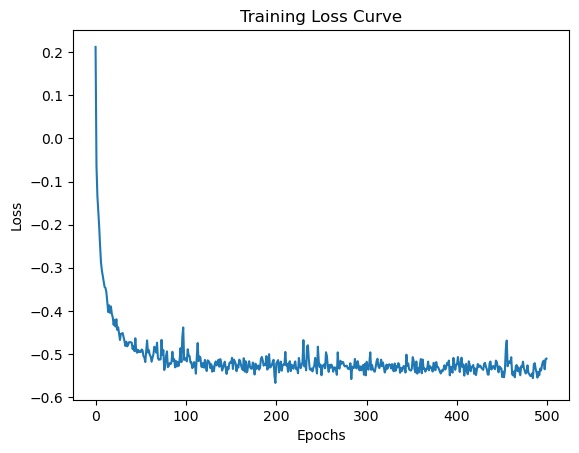

In [12]:
# Plot loss curve
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [13]:
# Generate new samples
with torch.no_grad():
    samples = model.sample(5000).cpu().numpy()

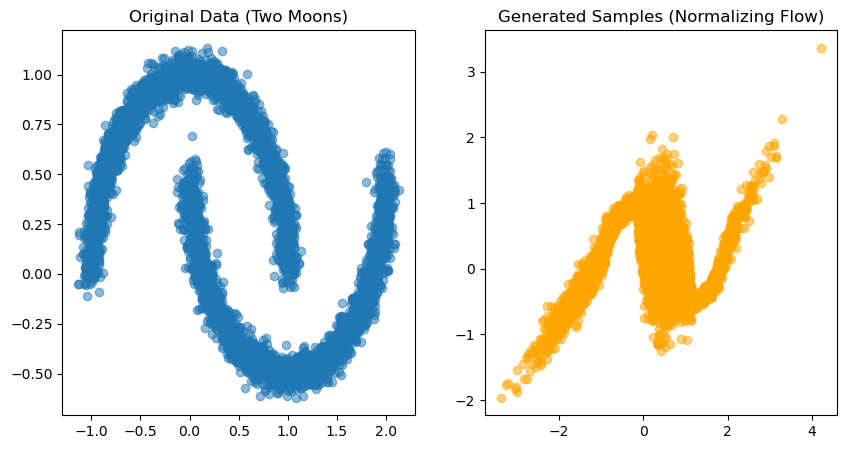

In [14]:
# Plot original data vs. generated samples
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].scatter(data.cpu()[:, 0], data.cpu()[:, 1], alpha=0.5)
ax[0].set_title("Original Data (Two Moons)")

ax[1].scatter(samples[:, 0], samples[:, 1], alpha=0.5, color='orange')
ax[1].set_title("Generated Samples (Normalizing Flow)")

plt.show()

## Example of Normalizing Flow Using MNIST Data

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
# Load MNIST dataset using TorchVision
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten images
])

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

In [18]:
# Define Affine Coupling Layer
class AffineCouplingLayer(nn.Module):
    def __init__(self, input_dim):
        super(AffineCouplingLayer, self).__init__()
        self.scale_net = nn.Sequential(nn.Linear(input_dim // 2, 256), nn.ReLU(), nn.Linear(256, input_dim // 2), nn.Tanh())
        self.translate_net = nn.Sequential(nn.Linear(input_dim // 2, 256), nn.ReLU(), nn.Linear(256, input_dim // 2))

    def forward(self, x, reverse=False):
        x1, x2 = x.chunk(2, dim=1)
        s = self.scale_net(x1)
        t = self.translate_net(x1)
        x2 = (x2 - t) / torch.exp(s) if reverse else x2 * torch.exp(s) + t
        return torch.cat([x1, x2], dim=1), s

In [19]:
# Define Normalizing Flow Model
class NormalizingFlow(nn.Module):
    def __init__(self, input_dim, num_layers):
        super(NormalizingFlow, self).__init__()
        self.layers = nn.ModuleList([AffineCouplingLayer(input_dim) for _ in range(num_layers)])

    def forward(self, x, reverse=False):
        log_det_jacobian = 0
        for layer in (reversed(self.layers) if reverse else self.layers):
            x, s = layer(x, reverse=reverse)
            log_det_jacobian += torch.sum(s, dim=1) if not reverse else -torch.sum(s, dim=1)
        return x, log_det_jacobian

    def sample(self, num_samples):
        z = torch.randn((num_samples, 784)).to(device)
        samples, _ = self.forward(z, reverse=True)
        return samples

In [20]:
# Train Normalizing Flow
input_dim, num_layers, epochs = 784, 4, 20
model = NormalizingFlow(input_dim, num_layers).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = lambda z, log_det: torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det)

losses = []
for epoch in range(epochs):
    batch_losses = []
    for batch, _ in train_loader:
        batch = batch.to(device)
        z, log_det = model(batch)
        loss = loss_fn(z, log_det)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    losses.append(np.mean(batch_losses))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

Epoch 1/20, Loss: -856.7831
Epoch 2/20, Loss: -954.6096
Epoch 3/20, Loss: -977.9733
Epoch 4/20, Loss: -991.6821
Epoch 5/20, Loss: -1002.5237
Epoch 6/20, Loss: -1011.8836
Epoch 7/20, Loss: -1019.5429
Epoch 8/20, Loss: -1026.0534
Epoch 9/20, Loss: -1033.0718
Epoch 10/20, Loss: -1038.1864
Epoch 11/20, Loss: -1043.5520
Epoch 12/20, Loss: -1047.9601
Epoch 13/20, Loss: -1051.6289
Epoch 14/20, Loss: -1055.9931
Epoch 15/20, Loss: -1059.2876
Epoch 16/20, Loss: -1062.8333
Epoch 17/20, Loss: -1066.0855
Epoch 18/20, Loss: -1068.6716
Epoch 19/20, Loss: -1071.4679
Epoch 20/20, Loss: -1074.1823


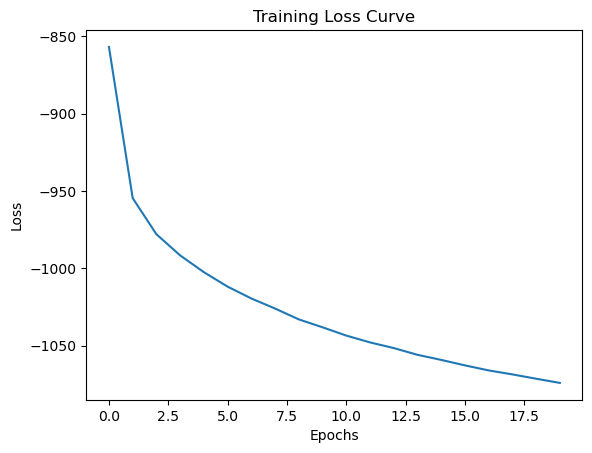

In [21]:
# Plot training loss
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [22]:
# Generate samples
with torch.no_grad():
    generated_samples = model.sample(25).cpu().numpy()

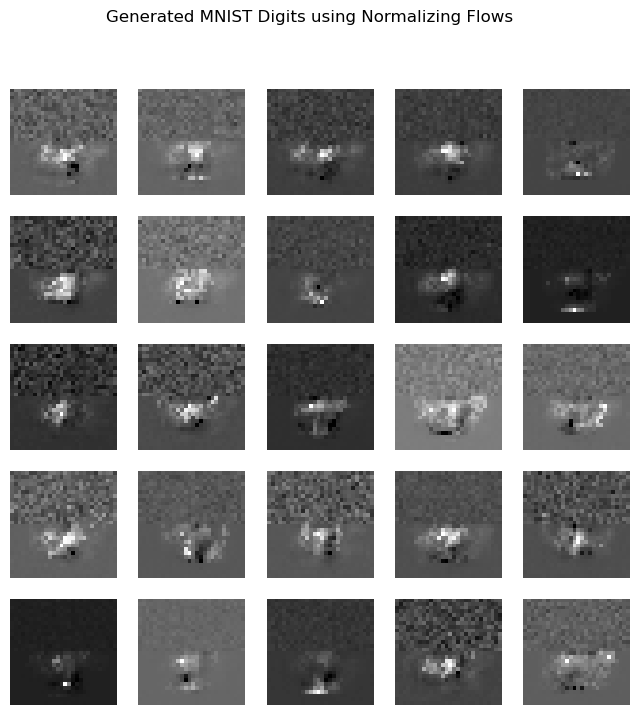

In [23]:
# Plot generated images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_samples[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle("Generated MNIST Digits using Normalizing Flows")
plt.show()

# Diffusion Models

Diffusion models are a class of **generative models** designed to **transform simple noise distributions into complex data distributions**. They do this through a **gradual denoising process**, where an initial noisy signal is iteratively refined into a structured output, such as an image or text.

#### Key Features of Diffusion Models
- **Probabilistic Modeling** – Models the data distribution via a **stochastic Markov process**.
- **Likelihood-Based** – Unlike GANs, diffusion models explicitly define a **probability density function**.
- **State-of-the-Art Generative Performance** – Used in cutting-edge models like **DALL·E 2, Stable Diffusion, Imagen, and Latent Diffusion Models**.

Diffusion models have been widely adopted for **image synthesis, text-to-image generation, molecular design, and speech synthesis**.

## Gradual Denoising

At the core of diffusion models is the idea of **gradual denoising**. Instead of generating data in one step, the model **starts with random noise** and progressively refines it over many small steps. To understand this process, the **forward diffusion process** corrupts data by adding noise while the **reverse diffusion process** learns to remove noise and reconstruct the data.

Overall, 
- The forward process **gradually corrupts** an image into pure noise.
- The reverse process **gradually reconstructs** an image by learning to remove noise.
- And, once trained, the model can **start from pure noise** and work to reconstruct meaningful samples.

![](https://cdn.prod.website-files.com/614c82ed388d53640613982e/66acbdfb02fc22886268621d_65609f066f555009dfa850ee_ddpms.webp)

### The Forward Diffusion Process: Adding Noise

The forward process systematically **destroys structure** in the data by adding **Gaussian noise** step by step:

$$
q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I)
$$

where:
- $ x_0 $ is the original data (e.g., an image from a dataset).
- $ x_t $ is the data at time step $ t $, containing progressively more noise.
- $ \beta_t $ is a small variance term controlling the noise added at each step.

#### What Happens During the Forward Process?
- **Initially, $ x_0 $ contains clear, structured data** (e.g., an image of a cat).
- At each time step $ t $, the data **loses detail** as Gaussian noise is added.
- After **T steps**, the data becomes indistinguishable from pure Gaussian noise.

We can directly sample noisy data from $ x_0 $ at any timestep $ t $ using:

$$
q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) I)
$$

where:

$$
\bar{\alpha}_t = \prod_{i=1}^{t} (1 - \beta_i)
$$

This formulation allows us to **skip multiple diffusion steps at once**, making training more efficient.

### The Reverse Diffusion Process: Learning to Remove Noise

Now, we need to **reverse this process** to recover the original image.

The goal is to model:

$$
p_\theta(x_{t-1} | x_t)
$$

which represents the probability of recovering a less noisy image $ x_{t-1} $ from a noisy image $ x_t $.

Since directly inverting the forward diffusion process is intractable, we **train a neural network** to predict the noise component added at each step:

$$
\epsilon_\theta(x_t, t) \approx \epsilon
$$

Using this predicted noise, we estimate $ x_{t-1} $ as:

$$
x_{t-1} = x_t - \epsilon_\theta(x_t, t)
$$

This step-by-step denoising process gradually reconstructs the original image from pure noise.

#### What Happens During the Reverse Process?
- **Start from Gaussian noise** $ x_T $.
- At each step, the model **removes a small amount of noise** from $ x_t $.
- After **T steps**, we recover a structured sample $ x_0 $ that resembles real data.

## How Diffusion Models Are Trained

Training a diffusion model boils down to teaching a neural network to **predict noise**. The model never sees the full denoising chain during training — instead, it learns one step at a time by looking at randomly selected snapshots of the noising process.

### The Training Objective

The loss function measures how well the model predicts the noise that was added to create a noisy image:

$$
L(\theta) = \mathbb{E}_{x_0, \epsilon, t} \left[ \|\epsilon - \epsilon_\theta(x_t, t) \|^2 \right]
$$

where:
- $x_0$ is a clean image from the training dataset.
- $t$ is a randomly chosen timestep (e.g., step 50 out of 1000).
- $\epsilon \sim \mathcal{N}(0, I)$ is the random Gaussian noise that was added.
- $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$ is the noisy version of the image at timestep $t$.
- $\epsilon_\theta(x_t, t)$ is the model's prediction of what noise was added.

In plain English: "Given this noisy image and the timestep, can you guess what the noise looks like?" The closer the prediction is to the actual noise, the lower the loss.

### Step-by-Step Training Procedure

Here is what happens during each training iteration:

| Step | Action | Details |
|------|--------|---------|
| 1 | **Sample a clean image** | Pick a random $x_0$ from the training dataset. |
| 2 | **Pick a random timestep** | Choose $t$ uniformly from $\{1, 2, \dots, T\}$. This means the model trains on all noise levels, not just early or late steps. |
| 3 | **Sample random noise** | Draw $\epsilon \sim \mathcal{N}(0, I)$ — pure Gaussian noise with the same dimensions as the image. |
| 4 | **Create the noisy image** | Compute $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$. This is a weighted blend of the clean image and noise, where higher $t$ means more noise. |
| 5 | **Predict the noise** | Feed $x_t$ and $t$ into the neural network $\epsilon_\theta$ to get its noise prediction. |
| 6 | **Compute the loss** | Calculate the mean squared error between the predicted noise and the actual noise: $\|\epsilon - \epsilon_\theta(x_t, t)\|^2$. |
| 7 | **Backpropagate and update** | Use standard gradient descent (e.g., Adam optimizer) to update the network's parameters $\theta$. |

### Why This Works

The elegance of this approach is its simplicity. A few key insights:

- **Random timestep selection** means the model sees every noise level during training. At $t=1$ the image is barely noisy; at $t=T$ it is nearly pure static. The model learns to handle them all.
- **The closed-form formula for $x_t$** (step 4) lets us jump directly from $x_0$ to any noise level without simulating all intermediate steps. This makes training much faster than running the full forward chain.
- **Predicting noise instead of the clean image** turns out to work better empirically. The network learns to identify patterns of noise at each scale, which is a simpler task than directly reconstructing pixel values.
- **The loss is derived from a variational bound** on the data log-likelihood $\log p(x_0)$. Minimizing this MSE loss is equivalent (up to a constant) to maximizing a lower bound on the probability that the model assigns to real data. So the model is doing principled probabilistic learning, not just curve fitting.

### After Training: How Generation Works

Once the model is trained, generating new images is straightforward:

1. **Start from pure noise:** sample $x_T \sim \mathcal{N}(0, I)$.
2. **Iteratively denoise:** for each step from $t = T$ down to $t = 1$, use the trained network to predict the noise component, subtract it (with appropriate scaling), and optionally add a small amount of fresh noise for stochasticity.
3. **Output:** after $T$ steps, $x_0$ is a generated image.

This iterative process is why diffusion models are slower to generate images than GANs (which produce an image in a single forward pass), but it is also why they tend to produce higher-quality and more diverse outputs — each denoising step gives the model a chance to refine details.

## Example of Diffusion Model Using Synthetic Data

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
# Generate Two Moons dataset
num_samples = 5000
data, _ = make_moons(n_samples=num_samples, noise=0.1)
data = torch.tensor(data, dtype=torch.float32).to(device)

In [26]:
# Define a simple U-Net-like neural network
class SimpleDiffusionModel(nn.Module):
    def __init__(self, input_dim):
        super(SimpleDiffusionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x, t):
        return self.net(x)

In [27]:
# Define the diffusion forward process (adds noise)
def forward_diffusion(x_0, t, noise):
    alpha_t = torch.exp(-0.5 * t)
    return alpha_t * x_0 + (1 - alpha_t) * noise

In [28]:
# Define the training loop for denoising
input_dim = 2
model = SimpleDiffusionModel(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 500
batch_size = 128
losses = []

for epoch in range(epochs):
    perm = torch.randperm(num_samples)
    batch_losses = []

    for i in range(0, num_samples, batch_size):
        idx = perm[i:i+batch_size]
        batch = data[idx].to(device)

        # Generate noisy input
        t = torch.rand(batch.shape[0], 1).to(device)  # Random timestep
        noise = torch.randn_like(batch).to(device)
        x_t = forward_diffusion(batch, t, noise)

        # Predict noise and compute loss
        pred_noise = model(x_t, t)
        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    avg_loss = np.mean(batch_losses)
    losses.append(avg_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")

Epoch 0: Loss = 0.8630
Epoch 50: Loss = 0.7642
Epoch 100: Loss = 0.7826
Epoch 150: Loss = 0.7601
Epoch 200: Loss = 0.7619
Epoch 250: Loss = 0.7437
Epoch 300: Loss = 0.7587
Epoch 350: Loss = 0.7727
Epoch 400: Loss = 0.7370
Epoch 450: Loss = 0.7633


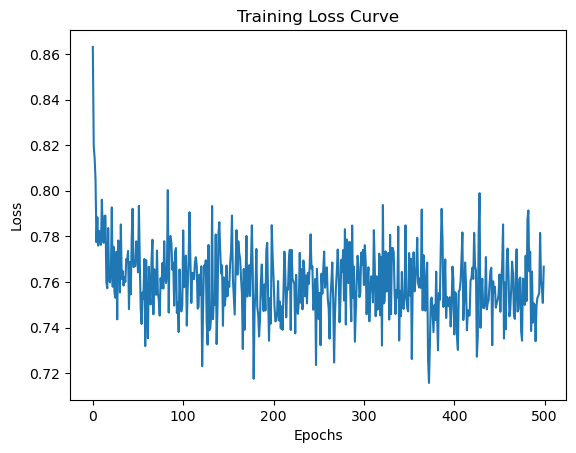

In [29]:
# Plot training loss
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [30]:
# Generate samples using reverse diffusion
def sample_diffusion(model, num_samples, steps=100):
    x = torch.randn((num_samples, 2)).to(device)  # Start from Gaussian noise
    for i in range(steps):
        t = torch.full((num_samples, 1), 1 - (i / steps)).to(device)
        noise_pred = model(x, t)
        x = x - noise_pred / steps  # Gradual denoising
    return x

with torch.no_grad():
    samples = sample_diffusion(model, 5000).cpu().numpy()

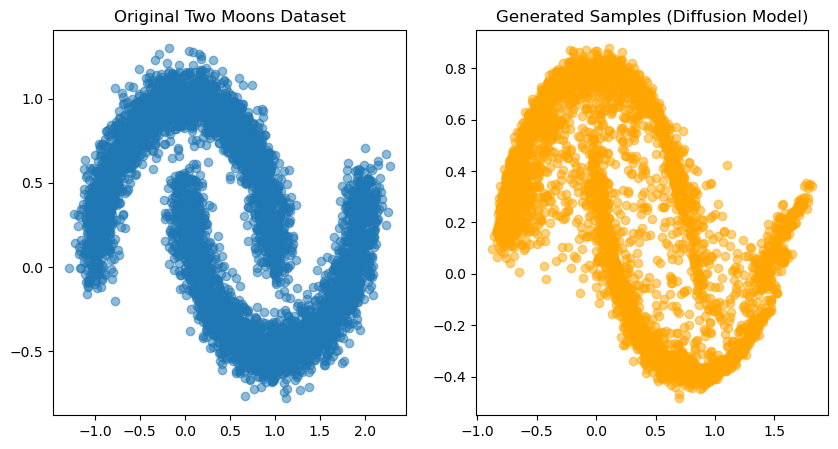

In [31]:
# Plot original vs. generated samples
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(data.cpu()[:, 0], data.cpu()[:, 1], alpha=0.5)
ax[0].set_title("Original Two Moons Dataset")

ax[1].scatter(samples[:, 0], samples[:, 1], alpha=0.5, color='orange')
ax[1].set_title("Generated Samples (Diffusion Model)")

plt.show()

## Example of Diffusion Model Using MNIST Data

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
# Load MNIST dataset using TorchVision
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten images
])

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

In [14]:
# Define Diffusion Model
class DiffusionModel(nn.Module):
    def __init__(self, input_dim):
        super(DiffusionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x, t):
        return self.net(x)

In [15]:
# Initialize model and optimizer
input_dim = 784  # 28x28 images flattened
model = DiffusionModel(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [16]:
# Training loop
epochs = 20
losses = []

for epoch in range(epochs):
    batch_losses = []
    for batch, _ in train_loader:
        batch = batch.to(device)
        t = torch.rand(batch.shape[0], 1).to(device)  # Random timestep
        noise = torch.randn_like(batch).to(device)
        x_t = batch * torch.sqrt(1 - t) + noise * torch.sqrt(t)

        pred_noise = model(x_t, t)
        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    losses.append(np.mean(batch_losses))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

Epoch 1/20, Loss: 0.7299
Epoch 2/20, Loss: 0.5952
Epoch 3/20, Loss: 0.5800
Epoch 4/20, Loss: 0.5768
Epoch 5/20, Loss: 0.5747
Epoch 6/20, Loss: 0.5739
Epoch 7/20, Loss: 0.5731
Epoch 8/20, Loss: 0.5726
Epoch 9/20, Loss: 0.5715
Epoch 10/20, Loss: 0.5716
Epoch 11/20, Loss: 0.5706
Epoch 12/20, Loss: 0.5703
Epoch 13/20, Loss: 0.5700
Epoch 14/20, Loss: 0.5693
Epoch 15/20, Loss: 0.5695
Epoch 16/20, Loss: 0.5689
Epoch 17/20, Loss: 0.5688
Epoch 18/20, Loss: 0.5693
Epoch 19/20, Loss: 0.5682
Epoch 20/20, Loss: 0.5684


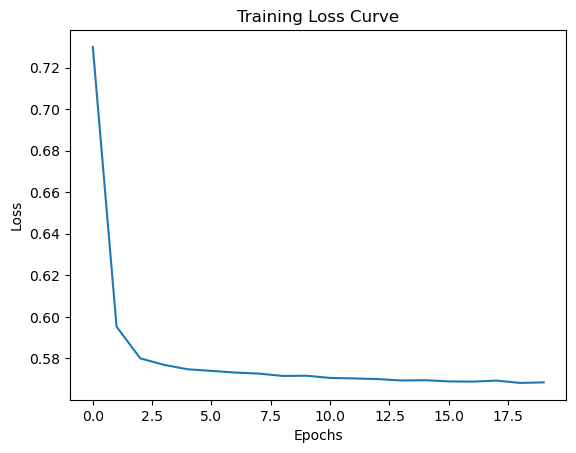

In [17]:
# Plot training loss
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [18]:
# Generate samples
def sample_diffusion(model, num_samples, steps=100):
    x = torch.randn((num_samples, 784)).to(device)  # Start with pure noise
    for i in range(steps):
        t = torch.full((num_samples, 1), 1 - (i / steps)).to(device)
        noise_pred = model(x, t)
        x = x - noise_pred / steps  # Gradual denoising
    return x

with torch.no_grad():
    generated_samples = sample_diffusion(model, 25).cpu().numpy()

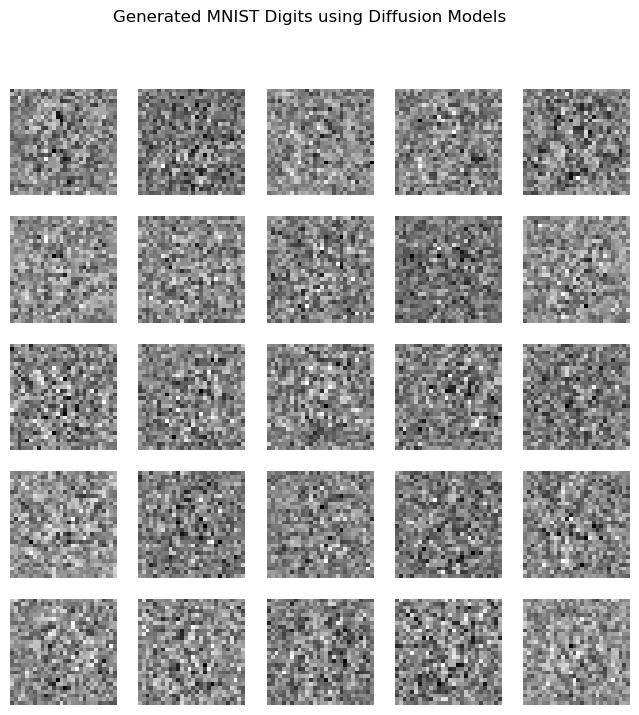

In [19]:
# Plot generated images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_samples[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle("Generated MNIST Digits using Diffusion Models")
plt.show()

## Diffusion Model Architectures

Different architectures are used to implement the neural network $ \epsilon_\theta(x_t, t) $. 

The most common is **U-Net**, but other variants exist.

### 1. U-Net for Diffusion Models

U-Net is a **convolutional neural network (CNN)** designed for image processing tasks, especially in segmentation and denoising. It is widely used in diffusion models.

#### U-Net Structure
- **Encoder Path (Contracting Path)**: Extracts hierarchical features using **convolutions and downsampling**.
- **Bottleneck**: Captures compressed feature representations.
- **Decoder Path (Expanding Path)**: Uses **upsampling and skip connections** to reconstruct the output.

#### Why U-Net?
- **Skip connections** allow for **information flow from high-resolution to low-resolution layers**, preserving fine-grained details.
- Works efficiently with **multi-scale features**, which is crucial for generating high-resolution images.
- Originally used for **medical image segmentation**, but adapted for **denoising and generative modeling**.

<img src="https://miro.medium.com/v2/resize:fit:920/1*W-RkwGIiKDF3A3WXwZQMWg.png" alt="Description" width="500">

### 2. Time-Conditioned Transformers

Recent diffusion models, like **Imagen and Stable Diffusion**, incorporate **transformer-based architectures** instead of CNNs.

#### How Transformers Improve Diffusion Models
- **Self-attention mechanisms** help model **long-range dependencies**.
- **Cross-attention** allows conditioning on text, enabling **text-to-image generation** (e.g., **DALL·E 2**).
- **Memory-efficient architectures** allow handling **high-resolution images**.

### 3. Latent Diffusion Models (LDMs)

Latent Diffusion Models (LDMs), like **Stable Diffusion**, introduce an additional step:

1. **Encode images into a low-dimensional latent space** using an autoencoder.
2. **Apply diffusion in this latent space** instead of pixel space.
3. **Decode the latent representation back into an image**.

This reduces the computational cost **without sacrificing quality**.

# Stable Diffusion

**Stable Diffusion** is one of the most widely used text-to-image generative models. Released by Stability AI in 2022 as an **open-source** model, it quickly became a landmark in AI image generation because anyone could download, run, and modify it — unlike proprietary alternatives.

## What Makes Stable Diffusion Different?

Stable Diffusion is built on the **Latent Diffusion Model (LDM)** architecture. The key innovation is that instead of running the diffusion process directly on full-resolution images (which is extremely expensive), it operates in a **compressed latent space**:

| Component | Role | Details |
|-----------|------|---------|
| **VAE Encoder** | Compresses the image | A pre-trained Variational Autoencoder encodes a 512×512 image into a much smaller latent representation (e.g., 64×64×4). This reduces computation by ~48× compared to pixel-space diffusion. |
| **U-Net** | Performs the denoising | The core diffusion model operates on the latent representation, iteratively removing noise. It uses **cross-attention layers** to incorporate text conditioning. |
| **Text Encoder (CLIP)** | Understands the prompt | A pre-trained CLIP text encoder converts the user's text prompt into a sequence of embedding vectors that guide the U-Net via cross-attention. |
| **VAE Decoder** | Reconstructs the image | After denoising is complete in latent space, the decoder maps the clean latent representation back to a full-resolution image. |

## How Does Stable Diffusion Work Step by Step?

1. **Text encoding:** The user's prompt (e.g., "A futuristic city at sunset") is passed through CLIP's text encoder to produce a sequence of token embeddings.
2. **Start with noise:** A random tensor is sampled in the latent space — this is the starting point.
3. **Iterative denoising:** The U-Net takes the noisy latent, the current timestep, and the text embeddings as input. It predicts the noise to subtract. This is repeated for a set number of steps (typically 20–50 with modern samplers).
4. **Decode to pixels:** The final clean latent is passed through the VAE decoder to produce the output image.

## Why Was Stable Diffusion a Breakthrough?

- **Open-source and runnable on consumer GPUs** — Unlike DALL-E 2 (API-only) or Midjourney (Discord-only), Stable Diffusion can run locally on a machine with 6–8 GB of VRAM.
- **Latent space diffusion** — Operating in compressed space made high-quality image generation computationally feasible without data center hardware.
- **Extensibility** — The open-source nature led to a massive ecosystem of community tools: ControlNet (pose/edge-guided generation), LoRA fine-tuning (personalized styles with small adapters), inpainting, img2img, and more.
- **Multiple versions** — Stable Diffusion has evolved through versions 1.4, 1.5, 2.0, 2.1, SDXL, and SD 3.0, each improving quality, resolution, and text understanding.

## Classifier-Free Guidance

A critical technique used in Stable Diffusion (and most modern diffusion models) is **classifier-free guidance (CFG)**. During generation, the model makes two noise predictions at each step — one conditioned on the text prompt and one unconditioned (empty prompt). The final prediction is:

$$
\epsilon_{\text{guided}} = \epsilon_{\text{uncond}} + w \cdot (\epsilon_{\text{cond}} - \epsilon_{\text{uncond}})
$$

where $w$ is the **guidance scale** (typically 7–12). Higher values make the output more closely follow the prompt but can reduce diversity. Lower values produce more varied but less prompt-faithful results.

### Resource

[Stable Diffusion Google Colab Notebook](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/stable_diffusion.ipynb)

# MidJourney

**MidJourney** is a proprietary AI image generation service founded by David Holz (co-founder of Leap Motion) and launched in mid-2022. It has become one of the most popular tools for AI art, known for producing highly stylized, aesthetically polished images out of the box.

## How Is MidJourney Different From Stable Diffusion?

| Aspect | MidJourney | Stable Diffusion |
|--------|-----------|-----------------|
| **Access** | Cloud-based service (originally Discord bot, now also a web app) | Open-source, runs locally or in the cloud |
| **Model** | Proprietary — architecture and training data are not publicly disclosed | Open-source — architecture papers, code, and weights are available |
| **Aesthetic quality** | Known for highly artistic, stylized default outputs | More neutral defaults; style depends on fine-tuning and prompting |
| **Customization** | Limited to prompt engineering and built-in parameters | Fully customizable — LoRA, ControlNet, custom training, etc. |
| **Cost** | Subscription-based ($10–$120/month depending on plan) | Free to run locally (hardware cost only) |

## How Does MidJourney Work?

While the exact architecture is proprietary, MidJourney is believed to use a diffusion-based approach similar in spirit to Stable Diffusion and DALL-E, with significant custom training and aesthetic fine-tuning. The general workflow:

1. **Prompt input:** The user provides a text description (e.g., "an oil painting of a lighthouse during a storm, dramatic lighting"). Through the Discord bot, this is done with the `/imagine` command; the web app has a standard text input.
2. **Image generation:** The model processes the prompt and generates a grid of **four image variations**.
3. **Refinement options:** The user can:
   - **Upscale (U1–U4):** Select one of the four images and generate a higher-resolution version.
   - **Variations (V1–V4):** Generate new variations of a selected image with slight differences.
   - **Reroll:** Generate an entirely new set of four images from the same prompt.
4. **Advanced parameters:** Users can control aspect ratio (`--ar 16:9`), stylization strength (`--stylize`), chaos/variety (`--chaos`), and more through command-line-style flags appended to the prompt.

## What Makes MidJourney Stand Out?

- **Aesthetic training:** MidJourney's models appear to be heavily fine-tuned for visual appeal. Even simple prompts tend to produce images with strong composition, lighting, and color harmony.
- **Version progression:** The model has gone through major versions (V1 through V6), with each version dramatically improving coherence, photorealism, and text rendering. V5 and V6 in particular brought near-photorealistic capabilities.
- **Community and curation:** The Discord-based interface created a built-in community where users share prompts and results, accelerating collective learning about effective prompting.
- **No technical setup required:** Unlike Stable Diffusion, there is nothing to install — users interact entirely through Discord or the web interface.

## Limitations

- **No local control:** You cannot run MidJourney on your own hardware or inspect the model.
- **Limited for research:** Because the model is closed-source, it cannot be used for academic research that requires reproducibility or architectural analysis.
- **Content policy:** MidJourney enforces content restrictions that may limit certain use cases.

### Resource

[MidJourney Quickstart Guide](https://docs.midjourney.com/hc/en-us/articles/33329261836941-Getting-Started-Guide)

# DALL-E

**DALL-E** is OpenAI's family of text-to-image models, with three major versions that illustrate the rapid evolution of generative image AI.

## The Evolution of DALL-E

### DALL-E 1 (January 2021)
The original DALL-E was a **12-billion parameter autoregressive transformer** — essentially a GPT-3-style model adapted for images. It treated image generation as a sequence prediction problem:
1. Text tokens from the prompt and image tokens (from a discrete VAE) were concatenated into a single sequence.
2. The transformer predicted image tokens one at a time, left to right, just like predicting the next word in a sentence.
3. The discrete VAE decoder converted the predicted tokens back into a full image.

This approach was groundbreaking for demonstrating that a single model could understand complex text prompts and generate creative visual interpretations, but the image quality was limited compared to later approaches.

### DALL-E 2 (April 2022)
DALL-E 2 switched to a **diffusion-based architecture** and produced dramatically better results:
1. **CLIP text encoder** converts the text prompt into an embedding.
2. A **prior model** maps the CLIP text embedding to a corresponding CLIP image embedding (bridging the gap between text and image representation spaces).
3. An **unCLIP diffusion decoder** generates an image conditioned on the CLIP image embedding, using a modified diffusion model.

Key capabilities introduced: **inpainting** (editing parts of an image), **outpainting** (extending an image beyond its borders), and **variations** (creating alternative versions of an uploaded image).

### DALL-E 3 (October 2023)
DALL-E 3 focused on dramatically improving **prompt fidelity** — how closely the generated image matches what the user actually asked for:
- **Trained on highly descriptive captions** — rather than short image labels, the training data used detailed captions generated by a captioning model, teaching DALL-E 3 to understand nuanced, specific prompts.
- **Integrated natively into ChatGPT** — ChatGPT automatically rewrites user prompts into detailed descriptions before passing them to DALL-E 3, which significantly improves output quality.
- **Better text rendering** — earlier models struggled to render legible text within images; DALL-E 3 significantly improved this capability.
- **Safety mitigations** — built-in filters to decline requests for images of real public figures and to reduce harmful content.

## How Does DALL-E Compare?

| Feature | DALL-E 3 | Stable Diffusion | MidJourney |
|---------|----------|-----------------|-----------|
| **Access** | API and ChatGPT integration | Open-source, local or cloud | Discord bot and web app |
| **Prompt understanding** | Excellent — benefits from ChatGPT rewriting | Good — depends on user prompting skill | Good — strong aesthetic defaults |
| **Customization** | Limited (API parameters only) | Extensive (LoRA, ControlNet, etc.) | Moderate (command flags) |
| **Cost** | Pay-per-image via API; included in ChatGPT Plus | Free locally; compute costs only | Subscription-based |
| **Text in images** | Best among the three | Struggles with text | Improved in V6 |

### Simple Example of Using DALL-E

In [20]:
from openai import OpenAI
import requests
from PIL import Image
from io import BytesIO

api_key=''

# Set up OpenAI client
client = OpenAI(api_key=api_key)

# Define a text prompt
prompt = "A futuristic city with flying cars and neon lights, cyberpunk style"

# Generate an image using OpenAI's DALL·E API
response = client.images.generate(
    model="dall-e-3",
    prompt=prompt,
    size="1024x1024",
    quality="standard",
    n=1,
)

# Get the image URL
image_url = response.data[0].url

# Download and display the generated image
image_response = requests.get(image_url)
image = Image.open(BytesIO(image_response.content))
image.show()

In [ ]:
image.show()

![](DALLEExample.png)

![](DALLE2.png)